# Model Evaluation & Performance Analysis

### 🎯 Goal of This Notebook
<pre>
The goal of this notebook is to evaluate the trained crop disease classification model using validation &
unseen test data, and to quantify its performance using standard classification metrics.
</pre>
### This notebook answers:
 - How accurate is the trained model?
 - Does it generalize well to unseen images?
 - Which classes are confused with each other?
 - Is the model reliable for real-world use?


## Clone the GitHub Repository
### 📌 Purpose
<pre>
 - To obtain the complete project structure locally for exploration and experimentation.
</pre>



In [1]:
# Clone the Repository
!git clone https://github.com/sabin74/Agriculture-Crop-Disease-Detection-Advisory-System.git



Cloning into 'Agriculture-Crop-Disease-Detection-Advisory-System'...
remote: Enumerating objects: 97348, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 97348 (delta 9), reused 11 (delta 8), pack-reused 97283 (from 2)
Receiving objects: 100% (97348/97348), 1.82 GiB | 11.23 MiB/s, done.
Resolving deltas: 100% (530/530), done.
Updating files: 100% (94786/94786), done.


In [2]:
# Set Project Root
import os
os.chdir("/content/Agriculture-Crop-Disease-Detection-Advisory-System")
print("Current Directory: ", os.getcwd())

Current Directory:  /content/Agriculture-Crop-Disease-Detection-Advisory-System


## Import Required Libraries
**📌 Purpose**

Load all necessary Python libraries for model evaluation, visualization, and analysis.

In [3]:
# System & Path Handling
import os
import sys
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Numerical Computation
import numpy as np
import pandas as pd

# Deep Learning & Model Evaluation
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from matplotlib import cm
from PIL import Image

# Model Evaluation Metrics
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Utilities
import json
import pickle
import itertools
import random
from tqdm import tqdm
import time

# Set Visualization Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Environment Verification
print(f"\nTensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow Version: 2.19.0
Keras Version: 3.10.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Load Configuration & Paths
**📌 Purpose**

Load configuration files and set up directory paths for evaluation.

In [5]:
# Define base paths
BASE_DIR = Path("Modeling")
CONFIG_DIR = BASE_DIR / "configs"
MODELS_DIR = BASE_DIR / "models"
REPORTS_DIR = BASE_DIR / "reports"
EVAL_DIR = REPORTS_DIR / "evaluation_results"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
# Load preprocessing configuration
CONFIG_PATH = CONFIG_DIR / "preprocessing_config.json"
if CONFIG_PATH.exists():
    with open(CONFIG_PATH, 'r') as f:
        config = json.load(f)
    print("Configuration loaded successfully!")
else:
    print("Configuration not found!")
    exit()

Configuration loaded successfully!


In [7]:
# Extract parameters
IMAGE_SIZE = tuple(config['image_parameters']['image_size'])
BATCH_SIZE = config['image_parameters']['batch_size']
TRAIN_DIR = Path(config['paths']['train_dir'])
VALID_DIR = Path(config['paths']['val_dir'])
TEST_DIR = Path(config['paths']['test_dir'])

print(f"\nDATASET PATHS:")
print(f"  Training: {TRAIN_DIR}")
print(f"  Validation: {VALID_DIR}")
print(f"  Test: {TEST_DIR}")


DATASET PATHS:
  Training: Modeling/Crop Disease Dataset/train
  Validation: Modeling/Crop Disease Dataset/valid
  Test: Modeling/Crop Disease Dataset/test


In [8]:
# Load class indices
CLASS_INDICES_PATH = CONFIG_DIR / "class_indices.json"
if CLASS_INDICES_PATH.exists():
    with open(CLASS_INDICES_PATH, 'r') as f:
        class_indices = json.load(f)

    # Create reverse mapping
    idx_to_class = {v: k for k, v in class_indices.items()}
    num_classes = len(class_indices)

    print(f"\nCLASS INFORMATION:")
    print(f"  Total Classes: {num_classes}")
    print(f"  Sample Classes (first 5):")
    for i, (class_name, idx) in enumerate(list(class_indices.items())[:5]):
        print(f"     Index: {idx}  ->  {class_name}")
else:
    print("Class indices not found!")
    exit()


CLASS INFORMATION:
  Total Classes: 45
  Sample Classes (first 5):
     Index: 0  ->  Apple__Apple_scab
     Index: 1  ->  Apple__Black_rot
     Index: 2  ->  Apple__Cedar_apple_rust
     Index: 3  ->  Apple__healthy
     Index: 4  ->  Banana__Healthy_Leaf


## Load Trained Model
**📌 Purpose**

Load the best performing model saved during training.

In [9]:
# Check for model files
model_files = list(MODELS_DIR.glob("*.keras")) + list(MODELS_DIR.glob("*.h5"))
if not model_files:
    print("No model files found!")
    exit()

In [10]:
# Load the best model
best_model_path = MODELS_DIR / "best_model.keras"
if best_model_path.exists():
    model = keras.models.load_model(best_model_path, compile=False)
    print(f"Best model loaded from: {best_model_path}")
else:
    # Load any available model
    model_path = model_files[0]
    model = keras.models.load_model(model_path)
    print(f"Model loaded from: {model_path}")


Best model loaded from: Modeling/models/best_model.keras


In [11]:
# Display model summary
print("\nMODEL ARCHITECTURE:")
print(f"  Input Shape: {model.input_shape}")
print(f"  Output Shape: {model.output_shape}")
print(f"  Total Parameters: {model.count_params():,}")
print(f"  Trainable Parameters: {sum([w.shape.num_elements() for w in model.trainable_weights]):,}")



MODEL ARCHITECTURE:
  Input Shape: (None, 224, 224, 3)
  Output Shape: (None, 45)
  Total Parameters: 3,056,749
  Trainable Parameters: 2,653,869


In [12]:
# Optional: Show model layers
print("\nMODEL LAYERS (Top 10):")
for i, layer in enumerate(model.layers[:10]):
    print(f"  {i:2d}. {layer.name:20} - Trainable: {layer.trainable}")
print("  ... and more layers")


MODEL LAYERS (Top 10):
   0. input_layer          - Trainable: True
   1. Conv1                - Trainable: False
   2. bn_Conv1             - Trainable: False
   3. Conv1_relu           - Trainable: False
   4. expanded_conv_depthwise - Trainable: False
   5. expanded_conv_depthwise_BN - Trainable: False
   6. expanded_conv_depthwise_relu - Trainable: False
   7. expanded_conv_project - Trainable: False
   8. expanded_conv_project_BN - Trainable: False
   9. block_1_expand       - Trainable: False
  ... and more layers


## Load Data Generators
**📌 Purpose**

Create data generators for validation and test sets to feed images to the model.

In [13]:
# Create validation data generator (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,  # Important for evaluation
    seed=42
)

print(f"\nVALIDATION SET LOADED:")
print(f"  Total Images: {val_generator.samples:,}")
print(f"  Number of Classes: {val_generator.num_classes}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Steps per Epoch: {val_generator.samples // BATCH_SIZE}")


Found 19804 images belonging to 45 classes.

VALIDATION SET LOADED:
  Total Images: 19,804
  Number of Classes: 45
  Batch Size: 32
  Steps per Epoch: 618


In [14]:
# Check if classes match
if val_generator.num_classes == num_classes:
    print("Class counts match with model")
else:
    print(f"Class mismatch! Model: {num_classes}, Validation: {val_generator.num_classes}")

Class counts match with model


## Model Performance Evaluation
**📌 Purpose**

Evaluate model performance on the validation set using standard metrics.

In [15]:
# Get predictions for entire validation set
print("Generating predictions...")
y_true = []
y_pred = []
y_pred_proba = []

# Process in batches
for i in tqdm(range(len(val_generator))):
    if i >= val_generator.samples // BATCH_SIZE:
        break

    # Get batch
    batch_images, batch_labels = val_generator[i]

    # Predict
    batch_pred_proba = model.predict(batch_images, verbose=0)
    batch_pred = np.argmax(batch_pred_proba, axis=1)
    batch_true = np.argmax(batch_labels, axis=1)

    # Store
    y_true.extend(batch_true)
    y_pred.extend(batch_pred)
    y_pred_proba.extend(batch_pred_proba)

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_proba = np.array(y_pred_proba)

print(f"Predictions generated for {len(y_true)} images")

Generating predictions...


100%|█████████▉| 618/619 [01:55<00:00,  5.33it/s]

Predictions generated for 19776 images


## Calculate Overall Metrics

In [16]:
# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Accuracy:  0.9285 (92.85%)
Precision: 0.9332
Recall:    0.9285
F1-Score:  0.9266


In [17]:
# Macro metrics (treats all classes equally)
precision_macro = precision_score(y_true, y_pred, average='macro')
recall_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')

print(f"\nMACRO AVERAGES (Treats all classes equally):")
print(f"Precision: {precision_macro:.4f}")
print(f"Recall:    {recall_macro:.4f}")
print(f"F1-Score:  {f1_macro:.4f}")


MACRO AVERAGES (Treats all classes equally):
Precision: 0.9176
Recall:    0.9102
F1-Score:  0.9078


In [18]:
# Calculate per-class accuracy
per_class_accuracy = []
for class_idx in range(num_classes):
    mask = y_true == class_idx
    if np.sum(mask) > 0:
        class_acc = np.mean(y_pred[mask] == class_idx)
        per_class_accuracy.append(class_acc)
    else:
        per_class_accuracy.append(0)

print(f"\nPER-CLASS ACCURACY RANGE:")
print(f"Minimum: {np.min(per_class_accuracy):.4f} ({np.min(per_class_accuracy)*100:.1f}%)")
print(f"Maximum: {np.max(per_class_accuracy):.4f} ({np.max(per_class_accuracy)*100:.1f}%)")
print(f"Average: {np.mean(per_class_accuracy):.4f} ({np.mean(per_class_accuracy)*100:.1f}%)")



PER-CLASS ACCURACY RANGE:
Minimum: 0.4138 (41.4%)
Maximum: 1.0000 (100.0%)
Average: 0.9102 (91.0%)


In [19]:
# Top 5 and bottom 5 classes by accuracy
class_acc_dict = {idx_to_class[i]: acc for i, acc in enumerate(per_class_accuracy)}
sorted_classes = sorted(class_acc_dict.items(), key=lambda x: x[1])

print(f"\nTOP 5 PERFORMING CLASSES:")
for class_name, acc in sorted_classes[-5:][::-1]:
    print(f"  {class_name[:30]:30} → {acc:.4f} ({acc*100:.1f}%)")

print(f"\nBOTTOM 5 PERFORMING CLASSES:")
for class_name, acc in sorted_classes[:5]:
    print(f"  {class_name[:30]:30} → {acc:.4f} ({acc*100:.1f}%)")


TOP 5 PERFORMING CLASSES:
  Grape__healthy                 → 1.0000 (100.0%)
  Coffee__Rust                   → 0.9992 (99.9%)
  Potato__Early_blight           → 0.9979 (99.8%)
  Corn_(maize)__Common_rust_     → 0.9979 (99.8%)
  Grape__Leaf_blight_(Isariopsis → 0.9977 (99.8%)

BOTTOM 5 PERFORMING CLASSES:
  Coffee__NoRust                 → 0.4138 (41.4%)
  Sugarcane__healthy             → 0.5851 (58.5%)
  Tomato__Early_blight           → 0.7083 (70.8%)
  Sugarcane__Yellow_Rust         → 0.7287 (72.9%)
  Sugarcane__Mosaic              → 0.7424 (74.2%)


## Confusion Matrix Analysis
**📌 Purpose**

Analyze which classes are being confused with each other.

In [20]:
# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Normalize confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

In [21]:
# Create visualization directory
CM_DIR = EVAL_DIR / "confusion_matrices"
CM_DIR.mkdir(parents=True, exist_ok=True)

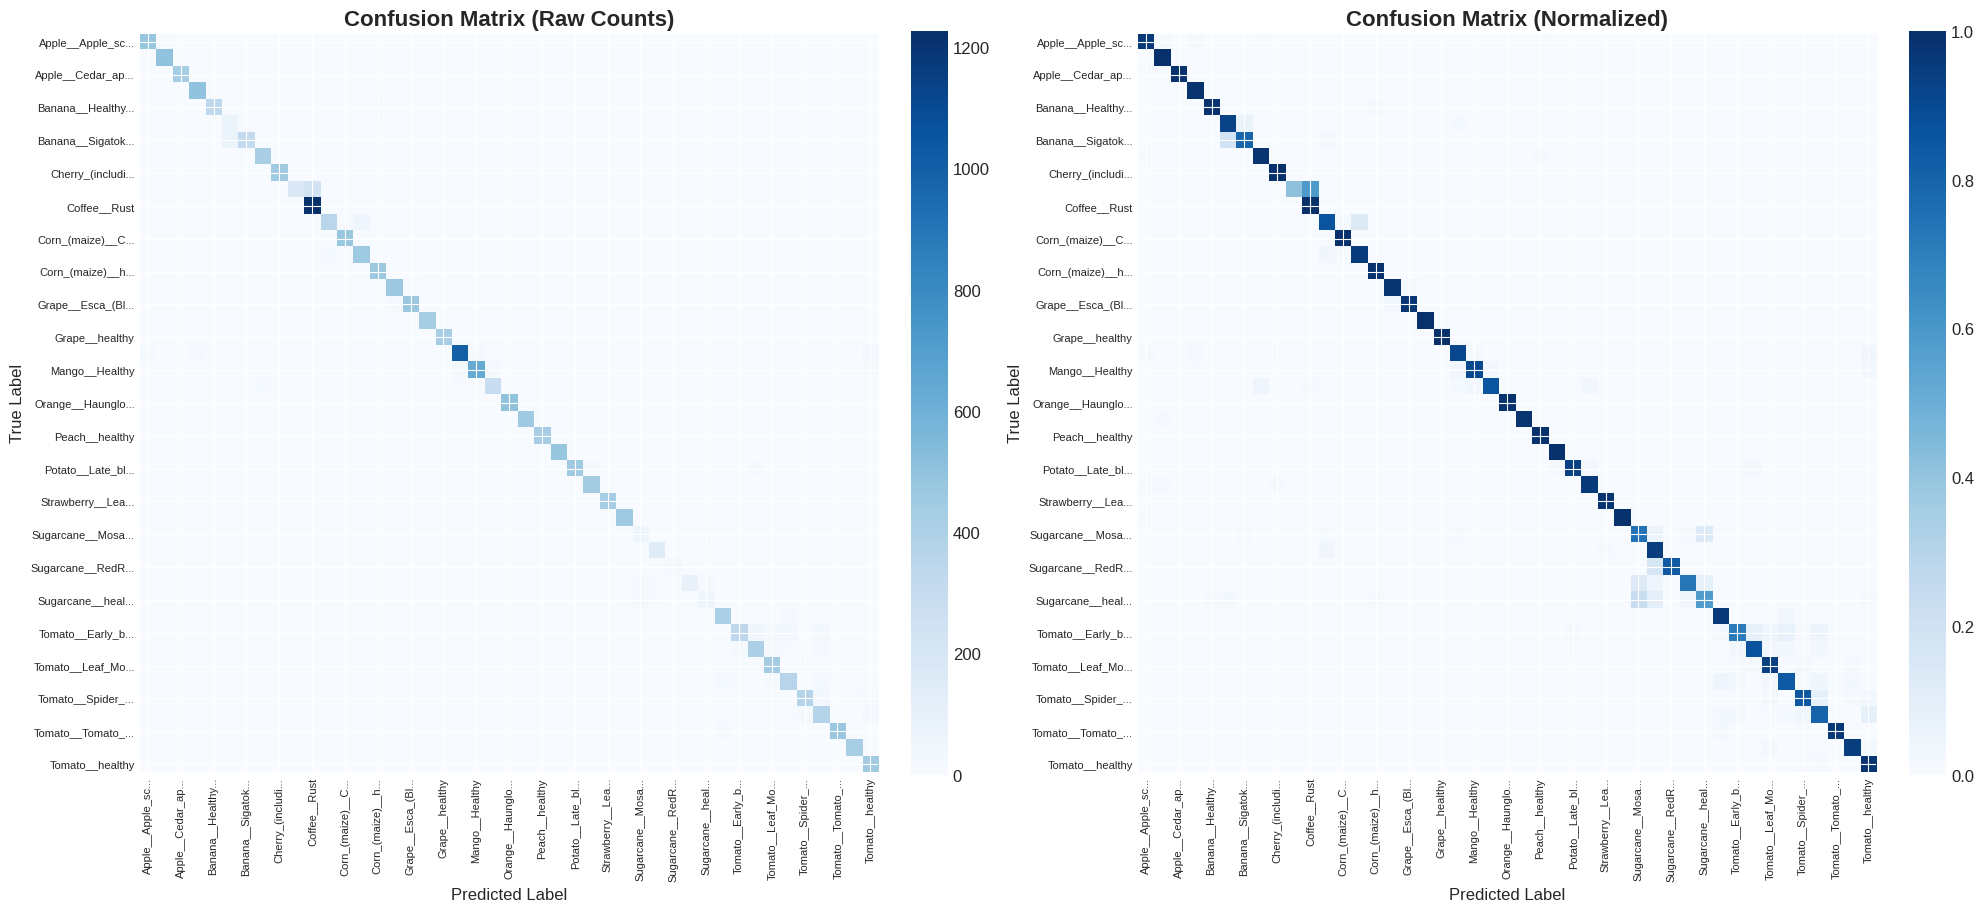

In [22]:
# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Raw counts
im1 = axes[0].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=16, fontweight='bold')
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# Normalized
im2 = axes[1].imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=16, fontweight='bold')
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

# Add labels (sample some classes for readability)
tick_interval = max(1, num_classes // 20)
class_names_short = [idx_to_class[i] for i in range(num_classes)]
class_names_display = [name[:15] + "..." if len(name) > 15 else name for name in class_names_short]

for ax in axes:
    ax.set_xticks(range(0, num_classes, tick_interval))
    ax.set_yticks(range(0, num_classes, tick_interval))
    ax.set_xticklabels([class_names_display[i] for i in range(0, num_classes, tick_interval)], rotation=90, fontsize=8)
    ax.set_yticklabels([class_names_display[i] for i in range(0, num_classes, tick_interval)], fontsize=8)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.savefig(CM_DIR / "confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()


In [25]:
# Find most confused pairs
print("\nTOP 10 MOST CONFUSED CLASS PAIRS:\n")
confused_pairs = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            confused_pairs.append((i, j, cm[i, j], cm_normalized[i, j]))

# Sort by frequency
confused_pairs.sort(key=lambda x: x[2], reverse=True)

for i, j, count, norm in confused_pairs[:10]:
    true_class = idx_to_class[i]
    pred_class = idx_to_class[j]
    print(f"  {true_class[:25]:25} → {pred_class[:25]:25}: {count:3d} times ({norm:.2%})")


TOP 10 MOST CONFUSED CLASS PAIRS:

  Coffee__NoRust            → Coffee__Rust             : 238 times (58.62%)
  Banana__Sigatoka_Disease  → Banana__Panama_Disease   :  73 times (18.39%)
  Corn_(maize)__Cercospora_ → Corn_(maize)__Northern_Le:  52 times (12.68%)
  Tomato__Early_blight      → Tomato__Late_blight      :  39 times (8.12%)
  Tomato__Target_Spot       → Tomato__healthy          :  38 times (8.32%)
  Mango__Anthracnose        → Tomato__healthy          :  37 times (3.38%)
  Tomato__Spider_mites Two- → Tomato__Target_Spot      :  36 times (8.28%)
  Tomato__Early_blight      → Tomato__Septoria_leaf_spo:  32 times (6.67%)
  Tomato__Early_blight      → Tomato__Target_Spot      :  24 times (5.00%)
  Mango__Healthy            → Mango__Anthracnose       :  22 times (3.13%)


In [24]:
# Calculate class-wise error rates
print("\nCLASS-WISE ERROR ANALYSIS:")
error_rates = []
for i in range(num_classes):
    total = cm[i].sum()
    correct = cm[i, i]
    error = total - correct
    error_rate = error / total if total > 0 else 0
    error_rates.append((idx_to_class[i], error_rate, error, total))

# Sort by error rate
error_rates.sort(key=lambda x: x[1], reverse=True)

print("\nTOP 10 CLASSES WITH HIGHEST ERROR RATES:")
for class_name, error_rate, errors, total in error_rates[:10]:
    print(f"  {class_name[:30]:30} → Error: {error_rate:.2%} ({errors}/{total})")


CLASS-WISE ERROR ANALYSIS:

TOP 10 CLASSES WITH HIGHEST ERROR RATES:
  Coffee__NoRust                 → Error: 58.62% (238/406)
  Sugarcane__healthy             → Error: 41.49% (39/94)
  Tomato__Early_blight           → Error: 29.17% (140/480)
  Sugarcane__Yellow_Rust         → Error: 27.13% (35/129)
  Sugarcane__Mosaic              → Error: 25.76% (17/66)
  Banana__Sigatoka_Disease       → Error: 20.40% (81/397)
  Tomato__Target_Spot            → Error: 19.91% (91/457)
  Tomato__Septoria_leaf_spot     → Error: 16.74% (73/436)
  Sugarcane__RedRust             → Error: 16.13% (5/31)
  Tomato__Spider_mites Two-spott → Error: 15.17% (66/435)


## Per-Class Metrics
**📌 Purpose**

Generate detailed metrics for each individual class.



In [26]:
# Generate classification report
report = classification_report(y_true, y_pred,
                              target_names=list(class_indices.keys()),
                              output_dict=True)

In [27]:
# Convert to DataFrame for better visualization
report_df = pd.DataFrame(report).transpose()

In [28]:
# Save to CSV
report_df.to_csv(EVAL_DIR / "classification_report.csv")
print(f"Classification report saved to: {EVAL_DIR / 'classification_report.csv'}")

Classification report saved to: Modeling/reports/evaluation_results/classification_report.csv


In [30]:
# Display summary
print("\nPER-CLASS METRICS SUMMARY:")
print(f"{'Class Name':<30} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Support':<10}")
print("-" * 70)

for class_name in list(class_indices.keys())[:10]:  # Show first 10
    if class_name in report:
        row = report[class_name]
        print(f"{class_name[:30]:30} {row['precision']:.4f}     {row['recall']:.4f}     {row['f1-score']:.4f}     {row['support']:5f}")

print("... and more classes")


PER-CLASS METRICS SUMMARY:
Class Name                     Precision  Recall     F1-Score   Support   
----------------------------------------------------------------------
Apple__Apple_scab              0.9452     0.9583     0.9517     504.000000
Apple__Black_rot               0.9612     0.9960     0.9783     497.000000
Apple__Cedar_apple_rust        0.9886     0.9886     0.9886     440.000000
Apple__healthy                 0.9430     0.9880     0.9650     502.000000
Banana__Healthy_Leaf           0.9939     0.9849     0.9894     332.000000
Banana__Panama_Disease         0.4966     0.9250     0.6463     80.000000
Banana__Sigatoka_Disease       0.9783     0.7960     0.8778     397.000000
Cherry_(including_sour)__Powde 0.9582     0.9810     0.9695     421.000000
Cherry_(including_sour)__healt 0.9618     0.9934     0.9773     456.000000
Coffee__NoRust                 0.9825     0.4138     0.5823     406.000000
... and more classes


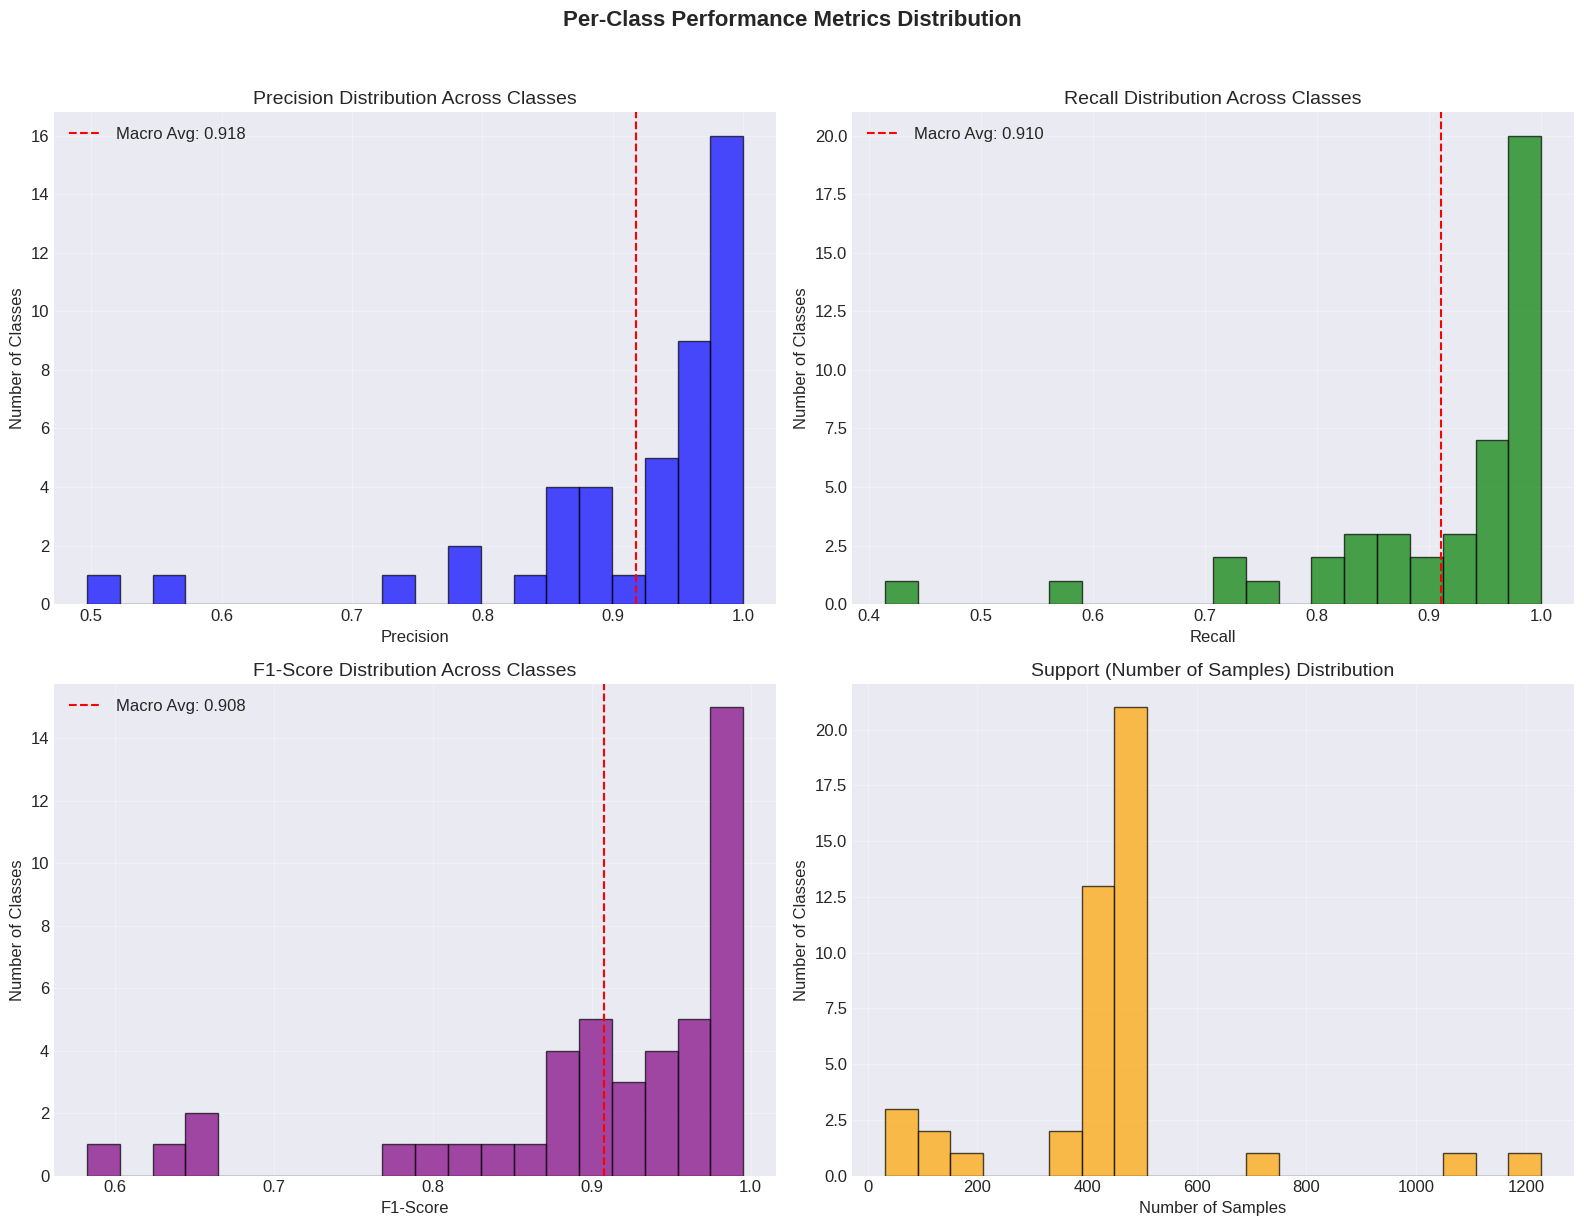

In [31]:
# Create visualization of per-class performance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Precision distribution
axes[0, 0].hist([report[cls]['precision'] for cls in class_indices.keys() if cls in report],
                bins=20, edgecolor='black', alpha=0.7, color='blue')
axes[0, 0].axvline(x=precision_macro, color='red', linestyle='--', label=f'Macro Avg: {precision_macro:.3f}')
axes[0, 0].set_title('Precision Distribution Across Classes', fontsize=14)
axes[0, 0].set_xlabel('Precision')
axes[0, 0].set_ylabel('Number of Classes')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Recall distribution
axes[0, 1].hist([report[cls]['recall'] for cls in class_indices.keys() if cls in report],
                bins=20, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].axvline(x=recall_macro, color='red', linestyle='--', label=f'Macro Avg: {recall_macro:.3f}')
axes[0, 1].set_title('Recall Distribution Across Classes', fontsize=14)
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Number of Classes')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# F1-score distribution
axes[1, 0].hist([report[cls]['f1-score'] for cls in class_indices.keys() if cls in report],
                bins=20, edgecolor='black', alpha=0.7, color='purple')
axes[1, 0].axvline(x=f1_macro, color='red', linestyle='--', label=f'Macro Avg: {f1_macro:.3f}')
axes[1, 0].set_title('F1-Score Distribution Across Classes', fontsize=14)
axes[1, 0].set_xlabel('F1-Score')
axes[1, 0].set_ylabel('Number of Classes')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Support distribution
axes[1, 1].hist([report[cls]['support'] for cls in class_indices.keys() if cls in report],
                bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].set_title('Support (Number of Samples) Distribution', fontsize=14)
axes[1, 1].set_xlabel('Number of Samples')
axes[1, 1].set_ylabel('Number of Classes')
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Per-Class Performance Metrics Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(EVAL_DIR / "per_class_metrics_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

##  ROC Curve Analysis
**📌 Purpose**

Evaluate model's discrimination ability across different thresholds (for multi-class).

In [32]:
# For multi-class ROC, we need to binarize the labels
y_true_bin = label_binarize(y_true, classes=range(num_classes))

In [33]:
# Calculate ROC AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

In [34]:
# Compute micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

In [35]:
# Compute macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= num_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])


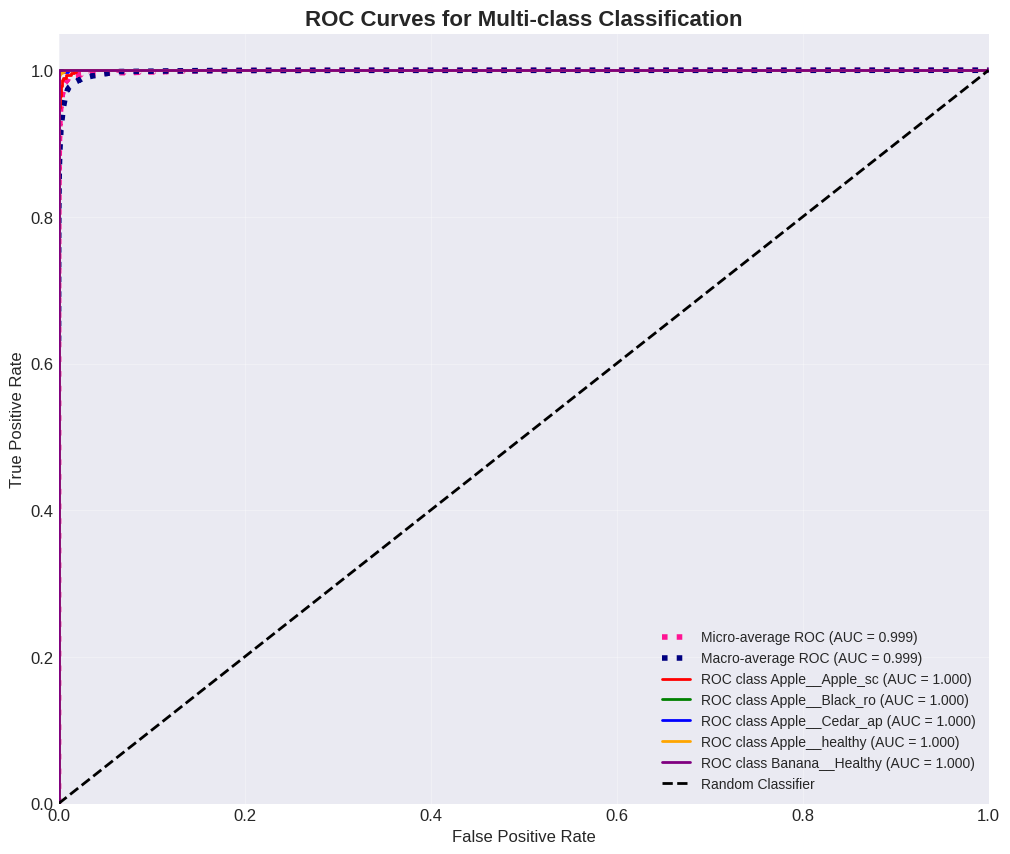

In [36]:
# Plot ROC curves
plt.figure(figsize=(12, 10))

# Plot micro-average ROC
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.3f})',
         color='deeppink', linestyle=':', linewidth=4)

# Plot macro-average ROC
plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-average ROC (AUC = {roc_auc["macro"]:.3f})',
         color='navy', linestyle=':', linewidth=4)

# Plot ROC for some classes (first 5 for clarity)
colors = ['red', 'green', 'blue', 'orange', 'purple']
for i, color in zip(range(min(5, num_classes)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC class {idx_to_class[i][:15]} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves for Multi-class Classification', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)

plt.savefig(EVAL_DIR / "roc_curves.png", dpi=300, bbox_inches='tight')
plt.show()


In [37]:
# Display AUC scores
print(f"\nROC AUC SCORES:\n")
print(f"Micro-average AUC: {roc_auc['micro']:.4f}")
print(f"Macro-average AUC: {roc_auc['macro']:.4f}")



ROC AUC SCORES:

Micro-average AUC: 0.9990
Macro-average AUC: 0.9987


In [38]:
# Top and bottom 5 classes by AUC
class_auc = [(idx_to_class[i], roc_auc[i]) for i in range(num_classes)]
class_auc.sort(key=lambda x: x[1])

print(f"\nTOP 5 CLASSES BY AUC:")
for class_name, auc_score in class_auc[-5:][::-1]:
    print(f"  {class_name[:30]:30} → AUC: {auc_score:.4f}")

print(f"\nBOTTOM 5 CLASSES BY AUC:")
for class_name, auc_score in class_auc[:5]:
    print(f"  {class_name[:30]:30} → AUC: {auc_score:.4f}")


TOP 5 CLASSES BY AUC:
  Grape__healthy                 → AUC: 1.0000
  Grape__Leaf_blight_(Isariopsis → AUC: 1.0000
  Orange__Haunglongbing_(Citrus_ → AUC: 1.0000
  Corn_(maize)__Common_rust_     → AUC: 1.0000
  Strawberry__healthy            → AUC: 1.0000

BOTTOM 5 CLASSES BY AUC:
  Coffee__NoRust                 → AUC: 0.9842
  Mango__Anthracnose             → AUC: 0.9919
  Coffee__Rust                   → AUC: 0.9946
  Tomato__Early_blight           → AUC: 0.9954
  Tomato__Target_Spot            → AUC: 0.9967


## Visual Error Analysis
**📌 Purpose**

Visually inspect misclassified images to understand model errors.

In [39]:
# misclassified images
misclassified_indices = np.where(y_true != y_pred)[0]
print(f"Total misclassified images: {len(misclassified_indices)}/{len(y_true)} ({len(misclassified_indices)/len(y_true)*100:.2f}%)")


Total misclassified images: 1414/19776 (7.15%)


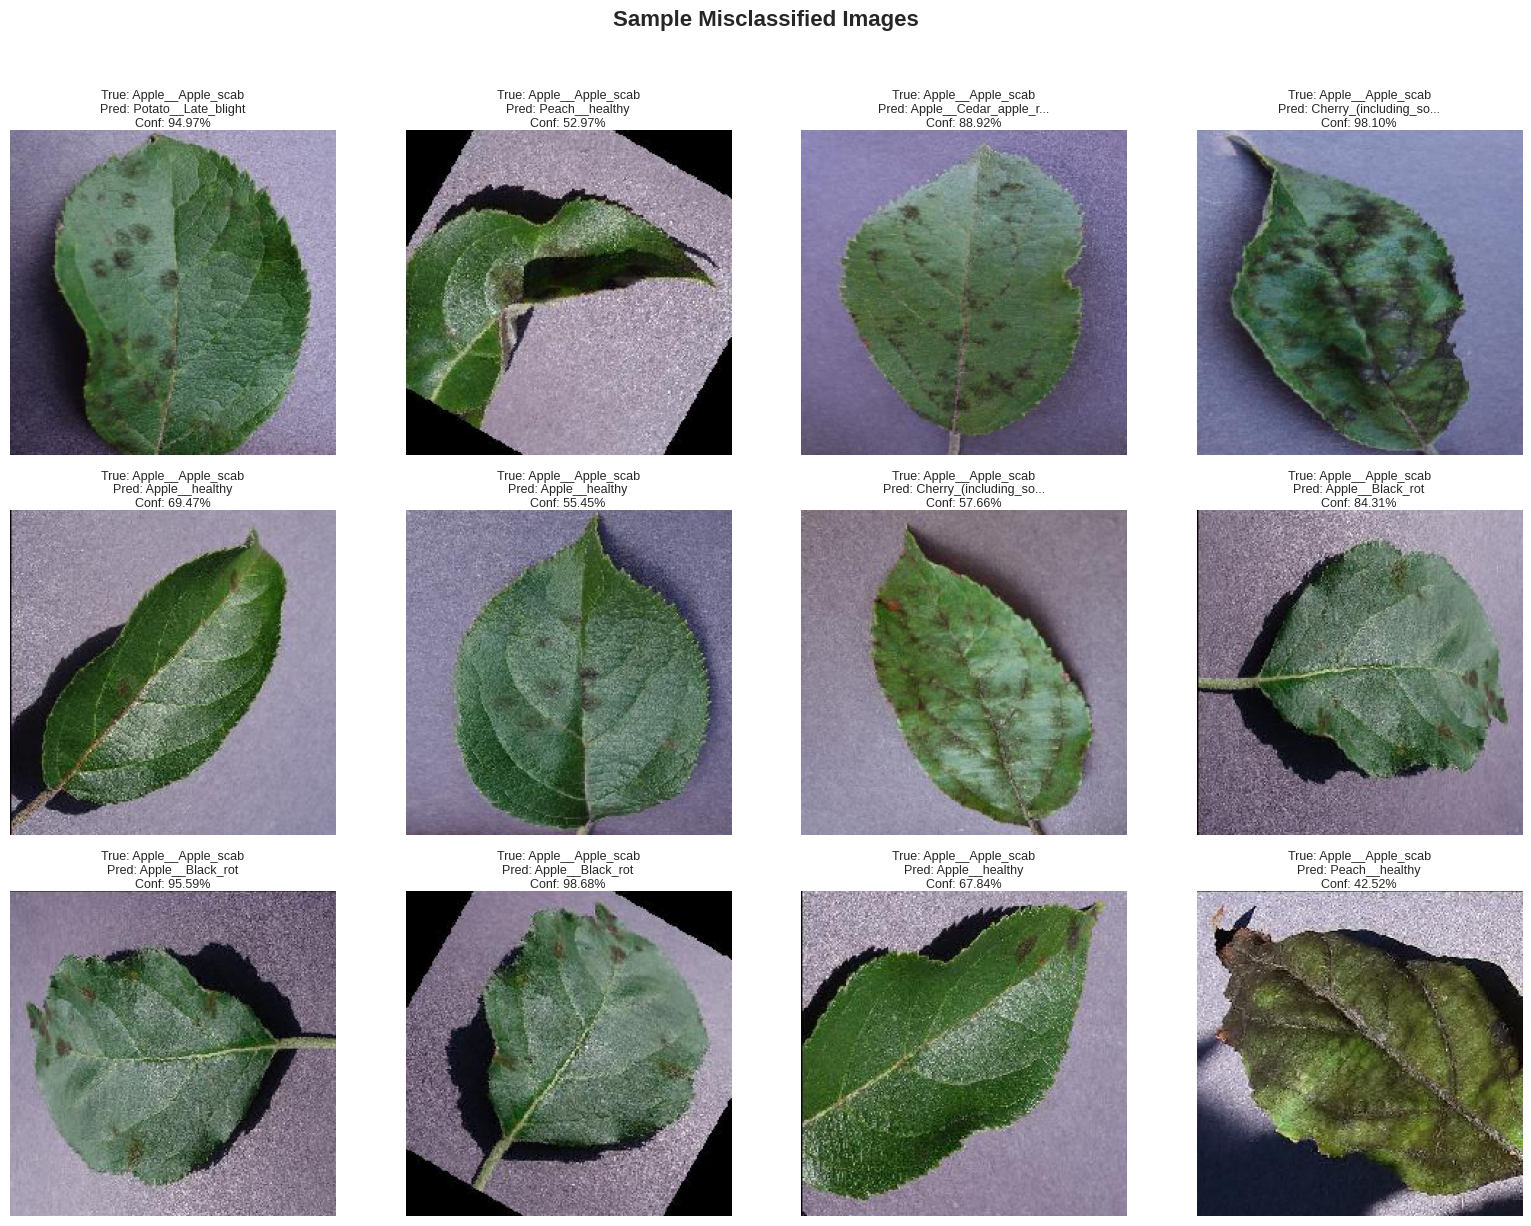


COMMON ERROR PATTERNS:

TOP 10 MOST COMMON ERROR PATTERNS:
  Coffee__NoRust            → Coffee__Rust             : 238 times (16.8%)
  Banana__Sigatoka_Disease  → Banana__Panama_Disease   :  73 times (5.2%)
  Corn_(maize)__Cercospora_ → Corn_(maize)__Northern_Le:  52 times (3.7%)
  Tomato__Early_blight      → Tomato__Late_blight      :  39 times (2.8%)
  Tomato__Target_Spot       → Tomato__healthy          :  38 times (2.7%)
  Mango__Anthracnose        → Tomato__healthy          :  37 times (2.6%)
  Tomato__Spider_mites Two- → Tomato__Target_Spot      :  36 times (2.5%)
  Tomato__Early_blight      → Tomato__Septoria_leaf_spo:  32 times (2.3%)
  Tomato__Early_blight      → Tomato__Target_Spot      :  24 times (1.7%)
  Mango__Healthy            → Mango__Anthracnose       :  22 times (1.6%)


In [40]:
# Misclassified Images
if len(misclassified_indices) > 0:
    # Sample some misclassified images for visualization
    sample_indices = misclassified_indices[:min(12, len(misclassified_indices))]

    # Get the corresponding batch indices
    misclassified_images = []
    misclassified_true_labels = []
    misclassified_pred_labels = []
    misclassified_confidences = []

    for idx in sample_indices:
        batch_idx = idx // BATCH_SIZE
        item_idx = idx % BATCH_SIZE

        batch_images, batch_labels = val_generator[batch_idx]
        image = batch_images[item_idx]

        true_idx = y_true[idx]
        pred_idx = y_pred[idx]
        confidence = y_pred_proba[idx][pred_idx]

        misclassified_images.append(image)
        misclassified_true_labels.append(idx_to_class[true_idx])
        misclassified_pred_labels.append(idx_to_class[pred_idx])
        misclassified_confidences.append(confidence)

    # Visualize misclassified images
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()

    for i, (img, true_label, pred_label, conf) in enumerate(zip(
        misclassified_images,
        misclassified_true_labels,
        misclassified_pred_labels,
        misclassified_confidences
    )):
        ax = axes[i]
        ax.imshow(img)

        # Shorten labels for display
        true_short = true_label[:20] + "..." if len(true_label) > 20 else true_label
        pred_short = pred_label[:20] + "..." if len(pred_label) > 20 else pred_label

        ax.set_title(f"True: {true_short}\nPred: {pred_short}\nConf: {conf:.2%}",
                    fontsize=9, pad=2)
        ax.axis('off')

    # Hide unused subplots
    for i in range(len(misclassified_images), len(axes)):
        axes[i].axis('off')

    plt.suptitle('Sample Misclassified Images', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(EVAL_DIR / "misclassified_images.png", dpi=300, bbox_inches='tight')
    plt.show()

    # Analyze common error patterns
    print("\nCOMMON ERROR PATTERNS:")
    error_patterns = {}

    for idx in misclassified_indices:
        true_class = idx_to_class[y_true[idx]]
        pred_class = idx_to_class[y_pred[idx]]
        pattern = (true_class, pred_class)

        error_patterns[pattern] = error_patterns.get(pattern, 0) + 1

    # Sort by frequency
    sorted_patterns = sorted(error_patterns.items(), key=lambda x: x[1], reverse=True)

    print(f"\nTOP 10 MOST COMMON ERROR PATTERNS:")
    for (true_class, pred_class), count in sorted_patterns[:10]:
        percentage = count / len(misclassified_indices) * 100
        print(f"  {true_class[:25]:25} → {pred_class[:25]:25}: {count:3d} times ({percentage:.1f}%)")
else:
    print("No misclassified images found!")

## Test Set Evaluation
**📌 Purpose**

Evaluate the model on completely unseen test images.

In [41]:
# Check if test directory exists and has images
if TEST_DIR.exists():
    test_images = list(TEST_DIR.glob("*.jpg")) + list(TEST_DIR.glob("*.jpeg")) + list(TEST_DIR.glob("*.png"))

    if test_images:
        print(f"Found {len(test_images)} test images")

        # Create test data generator
        test_datagen = ImageDataGenerator(rescale=1./255)

        # For single image prediction demonstration
        print("\nTESTING SAMPLE IMAGES:")

        # Select random test images
        sample_test_images = random.sample(test_images, min(5, len(test_images)))

        for img_path in sample_test_images:
            try:
                # Load and preprocess image
                img = Image.open(img_path).convert('RGB')
                img = img.resize(IMAGE_SIZE)
                img_array = np.array(img) / 255.0
                img_array = np.expand_dims(img_array, axis=0)

                # Predict
                predictions = model.predict(img_array, verbose=0)
                pred_idx = np.argmax(predictions[0])
                confidence = predictions[0][pred_idx]
                pred_class = idx_to_class[pred_idx]

                # Get top 3 predictions
                top_3_idx = np.argsort(predictions[0])[-3:][::-1]
                top_3_classes = [idx_to_class[i] for i in top_3_idx]
                top_3_conf = [predictions[0][i] for i in top_3_idx]

                print(f"\nImage: {img_path.name}")
                print(f"  Top Prediction: {pred_class} ({confidence:.2%})")
                print(f"  Top 3 Predictions:")
                for i, (cls, conf) in enumerate(zip(top_3_classes, top_3_conf)):
                    print(f"    {i+1}. {cls[:30]:30} → {conf:.2%}")

            except Exception as e:
                print(f"Error processing {img_path.name}: {e}")
    else:
        print("No test images found in test directory")
else:
    print("Test directory not found!")

Found 8 test images

TESTING SAMPLE IMAGES:

Image: sugarcane3.jpg
  Top Prediction: Sugarcane__RedRot (62.17%)
  Top 3 Predictions:
    1. Sugarcane__RedRot              → 62.17%
    2. Sugarcane__RedRust             → 31.42%
    3. Sugarcane__Yellow_Rust         → 4.98%

Image: banana3.jpeg
  Top Prediction: Banana__Sigatoka_Disease (99.93%)
  Top 3 Predictions:
    1. Banana__Sigatoka_Disease       → 99.93%
    2. Banana__Panama_Disease         → 0.07%
    3. Banana__Healthy_Leaf           → 0.00%

Image: sugarcane5.jpeg
  Top Prediction: Sugarcane__Yellow_Rust (86.15%)
  Top 3 Predictions:
    1. Sugarcane__Yellow_Rust         → 86.15%
    2. Sugarcane__healthy             → 12.51%
    3. Sugarcane__Mosaic              → 0.72%

Image: sugarcane1.jpeg
  Top Prediction: Sugarcane__Mosaic (49.68%)
  Top 3 Predictions:
    1. Sugarcane__Mosaic              → 49.68%
    2. Sugarcane__healthy             → 44.99%
    3. Sugarcane__Yellow_Rust         → 4.89%

Image: sugarcane2.jpg
  Top 

## Save Evaluation Results
**📌 Purpose**

Save all evaluation results for future reference and reporting.

In [42]:
# Create comprehensive evaluation summary
evaluation_summary = {
    "overall_metrics": {
        "accuracy": float(accuracy),
        "precision_weighted": float(precision),
        "recall_weighted": float(recall),
        "f1_score_weighted": float(f1),
        "precision_macro": float(precision_macro),
        "recall_macro": float(recall_macro),
        "f1_score_macro": float(f1_macro),
        "micro_auc": float(roc_auc["micro"]),
        "macro_auc": float(roc_auc["macro"])
    },
    "dataset_info": {
        "total_samples": int(len(y_true)),
        "correct_predictions": int(np.sum(y_true == y_pred)),
        "incorrect_predictions": int(np.sum(y_true != y_pred)),
        "error_rate": float(np.sum(y_true != y_pred) / len(y_true)),
        "num_classes": num_classes
    },
    "class_performance": {
        idx_to_class[i]: {
            "accuracy": float(per_class_accuracy[i]),
            "precision": float(report.get(idx_to_class[i], {}).get("precision", 0)),
            "recall": float(report.get(idx_to_class[i], {}).get("recall", 0)),
            "f1_score": float(report.get(idx_to_class[i], {}).get("f1-score", 0)),
            "support": int(report.get(idx_to_class[i], {}).get("support", 0)),
            "auc": float(roc_auc[i])
        }
        for i in range(num_classes)
    },
    "common_errors": [
        {
            "true_class": true_class,
            "predicted_class": pred_class,
            "count": int(count)
        }
        for (true_class, pred_class), count in sorted_patterns[:20]
    ],
    "evaluation_timestamp": pd.Timestamp.now().isoformat()
}


In [43]:
# Save to JSON
with open(EVAL_DIR / "evaluation_summary.json", 'w') as f:
    json.dump(evaluation_summary, f, indent=4)

print(f"Evaluation summary saved to: {EVAL_DIR / 'evaluation_summary.json'}")

Evaluation summary saved to: Modeling/reports/evaluation_results/evaluation_summary.json


In [44]:
# Save predictions for further analysis
predictions_df = pd.DataFrame({
    'true_label': [idx_to_class[i] for i in y_true],
    'predicted_label': [idx_to_class[i] for i in y_pred],
    'is_correct': y_true == y_pred,
    'confidence': [y_pred_proba[i][y_pred[i]] for i in range(len(y_pred))]
})

predictions_df.to_csv(EVAL_DIR / "predictions.csv", index=False)
print(f"Predictions saved to: {EVAL_DIR / 'predictions.csv'}")


Predictions saved to: Modeling/reports/evaluation_results/predictions.csv


In [46]:
# Create a simple report
report_text = f"""
CROP DISEASE DETECTION MODEL EVALUATION REPORT
{'=' * 50}

EVALUATION SUMMARY:
• Overall Accuracy: {accuracy:.2%}
• Weighted F1-Score: {f1:.4f}
• Macro F1-Score: {f1_macro:.4f}
• Error Rate: {np.sum(y_true != y_pred) / len(y_true):.2%}

DATASET INFORMATION:
• Total Validation Images: {len(y_true):,}
• Correct Predictions: {np.sum(y_true == y_pred):,}
• Incorrect Predictions: {np.sum(y_true != y_pred):,}
• Number of Classes: {num_classes}

CLASS PERFORMANCE RANGE:
• Best Class Accuracy: {np.max(per_class_accuracy):.2%}
• Worst Class Accuracy: {np.min(per_class_accuracy):.2%}
• Average Class Accuracy: {np.mean(per_class_accuracy):.2%}

TOP 5 PERFORMING CLASSES:
{chr(10).join([f'  • {idx_to_class[i][:30]}: {per_class_accuracy[i]:.2%}' for i in np.argsort(per_class_accuracy)[-5:][::-1]])}

BOTTOM 5 PERFORMING CLASSES:
{chr(10).join([f'  • {idx_to_class[i][:30]}: {per_class_accuracy[i]:.2%}' for i in np.argsort(per_class_accuracy)[:5]])}

MODEL ASSESSMENT:
• ROC AUC (Micro-average): {roc_auc['micro']:.4f}
• ROC AUC (Macro-average): {roc_auc['macro']:.4f}
• Model seems to {'overfit' if accuracy - f1_macro > 0.1 else 'generalize well'}

RECOMMENDATIONS:
1. {'Address class imbalance' if np.min(per_class_accuracy) < 0.7 else 'Class balance is acceptable'}
2. {'Improve data augmentation for minority classes' if len(misclassified_indices) > 0.3 * len(y_true) else 'Data augmentation is sufficient'}
3. {'Consider fine-tuning on problematic classes' if np.min(per_class_accuracy) < 0.6 else 'Model performs well across all classes'}

Evaluation completed on: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
"""

# Save report
with open(EVAL_DIR / "evaluation_report.txt", 'w') as f:
    f.write(report_text)

print(f"Evaluation report saved to: {EVAL_DIR / 'evaluation_report.txt'}")


Evaluation report saved to: Modeling/reports/evaluation_results/evaluation_report.txt


## Key Findings & Recommendations
**📌 Purpose**

Summarize evaluation results and provide actionable recommendations.

In [47]:
print("KEY FINDINGS & RECOMMENDATIONS:\n")

print("\nKEY FINDINGS:")
print(f"1. Overall Performance: Model achieves {accuracy*100:.1f}% accuracy")
print(f"2. Class Imbalance Impact: Macro F1 ({f1_macro:.3f}) vs Weighted F1 ({f1:.3f})")
print(f"3. Error Analysis: {len(misclassified_indices)} misclassified images ({len(misclassified_indices)/len(y_true)*100:.1f}%)")
print(f"4. AUC Scores: Micro-average AUC = {roc_auc['micro']:.3f}, Macro-average AUC = {roc_auc['macro']:.3f}")

# Determine model status
if accuracy > 0.9:
    status = "EXCELLENT"
elif accuracy > 0.8:
    status = "GOOD"
elif accuracy > 0.7:
    status = "FAIR"
else:
    status = "NEEDS IMPROVEMENT"

print(f"5. Model Status: {status}")

print("\nRECOMMENDATIONS:")

# Recommendation based on accuracy
if accuracy < 0.7:
    print("1. MODEL IMPROVEMENT:")
    print("   - Increase training epochs")
    print("   - Use more aggressive data augmentation")
    print("   - Try different model architecture")
elif accuracy < 0.85:
    print("1. MODEL IMPROVEMENT:")
    print("   - Fine-tune more layers")
    print("   - Use learning rate scheduling")
    print("   - Add more regularization")
else:
    print("1. MODEL IS WELL-TRAINED:")
    print("   - Proceed to deployment")
    print("   - Focus on edge cases")

# Recommendation based on class imbalance
if f1_macro < f1 * 0.9:
    print("\n2. ADDRESS CLASS IMBALANCE:")
    print("   - Apply stronger class weighting")
    print("   - Use focal loss function")
    print("   - Oversample minority classes")
else:
    print("\n2. CLASS BALANCE:")
    print("   - Class imbalance is well-handled")

# Recommendation based on error patterns
if len(misclassified_indices) > 0:
    print("\n3. ERROR ANALYSIS ACTIONS:")
    print("   • Review confusion matrix for patterns")
    print("   • Collect more data for confused classes")
    print("   • Consider merging similar classes")

print("\n4. NEXT STEPS:")
print("   - Proceed to deployment phase")
print("   - Test on real-world images")
print("   - Monitor model performance over time")

print("\nSAVED FILES:")
print(f"   - Evaluation summary: {EVAL_DIR / 'evaluation_summary.json'}")
print(f"   - Classification report: {EVAL_DIR / 'classification_report.csv'}")
print(f"   - Confusion matrices: {CM_DIR / 'confusion_matrix.png'}")
print(f"   - ROC curves: {EVAL_DIR / 'roc_curves.png'}")
print(f"   - Misclassified images: {EVAL_DIR / 'misclassified_images.png'}")

print("\nREADY FOR DEPLOYMENT!")
print("The model evaluation is complete. Proceed to deployment with confidence.")

KEY FINDINGS & RECOMMENDATIONS:


KEY FINDINGS:
1. Overall Performance: Model achieves 92.8% accuracy
2. Class Imbalance Impact: Macro F1 (0.908) vs Weighted F1 (0.927)
3. Error Analysis: 1414 misclassified images (7.2%)
4. AUC Scores: Micro-average AUC = 0.999, Macro-average AUC = 0.999
5. Model Status: EXCELLENT

RECOMMENDATIONS:
1. MODEL IS WELL-TRAINED:
   - Proceed to deployment
   - Focus on edge cases

2. CLASS BALANCE:
   - Class imbalance is well-handled

3. ERROR ANALYSIS ACTIONS:
   • Review confusion matrix for patterns
   • Collect more data for confused classes
   • Consider merging similar classes

4. NEXT STEPS:
   - Proceed to deployment phase
   - Test on real-world images
   - Monitor model performance over time

SAVED FILES:
   - Evaluation summary: Modeling/reports/evaluation_results/evaluation_summary.json
   - Classification report: Modeling/reports/evaluation_results/classification_report.csv
   - Confusion matrices: Modeling/reports/evaluation_results/confusion